# SGP Denominator Analysis

Compute Standings Gain Points (SGP) denominators from imported Yahoo league standings data and sanity-check whether they're reasonable for fantasy baseball valuation.

**SGP denominator** = mean gap between adjacent teams in a category's standings. It answers: "How many more HR (or lower ERA) does it take to gain one standings point?"

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = "/Users/edward/Projects/fbm/data/fbm.db"
conn = __import__("sqlite3").connect(DB_PATH)

# Load all standings data
df = pd.read_sql(
    "SELECT season, league_key, team_key, team_name, final_rank, stat_values_json FROM yahoo_team_season_stats",
    conn,
)
print(f"Loaded {len(df)} team-season rows across {df['season'].nunique()} seasons")
df["season"].value_counts().sort_index()

Loaded 218 team-season rows across 15 seasons


season
2012    10
2013    10
2014    10
2015    14
2016    14
2017    14
2018    14
2019    14
2020    12
2021    12
2022    14
2023    14
2024    14
2025    26
2026    26
Name: count, dtype: int64

In [2]:
# Explode stat_values_json into columns
stats = df["stat_values_json"].apply(json.loads).apply(pd.Series)
df = pd.concat([df.drop(columns=["stat_values_json"]), stats], axis=1)

# Show available categories and a sample
stat_cols = [c for c in stats.columns if c not in ("team_key", "league_key", "season", "team_name", "final_rank")]
print(f"Categories: {sorted(stat_cols)}")
df[["season", "team_name", "final_rank"] + sorted(stat_cols)].head(10)

Categories: ['era', 'hr', 'ip', 'obp', 'r', 'rbi', 'sb', 'so', 'sv+hld', 'w', 'whip']


,season,team_name,final_rank,era,hr,ip,obp,r,rbi,sb,so,sv+hld,w,whip
0,2026,Let Shohei Pitch,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026,Acuña Matada,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026,Bargain Bangers,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026,Buehrle 18,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026,Coffee's for Closers,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026,Ex-Mr Jennifer Lopez,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2026,Les Sexpos de Montréal,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2026,Lil XanDrew McCutchen,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2026,Macon Mustaches,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026,Norfolk Southern DerailRiders,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Compute SGP Denominators

For each category and season:
1. Sort teams by the category value (ascending for counting stats, descending for rate stats where lower is better)
2. Compute gaps between adjacent teams
3. Take the mean gap — this is the SGP denominator

"Lower is better" categories (ERA, WHIP) get their gaps negated so the denominator is positive and represents "how much must your ERA *decrease* to gain 1 SGP."

In [3]:
LOWER_IS_BETTER = {"era", "whip"}

# Focus on the redraft league only (exclude keeper which has fewer seasons)
redraft = df[
    df["league_key"].str.contains(
        "91300|14364|42042|39204|32625|52284|42486|117817|95108|64907|100552|98505|117570|114166|180597"
    )
]
# Simpler: just use the league with most seasons per league_key chain
# Actually let's just filter to completed seasons (exclude 2026 in-progress and 2025 if it's the current season)
completed = df[df["season"] <= 2025].copy()
print(f"Using {len(completed)} team rows across seasons {sorted(completed['season'].unique())}")


def compute_sgp_denominator(group: pd.DataFrame, cat: str) -> float:
    """Compute mean adjacent gap for one category in one season."""
    sorted_vals = group[cat].dropna().sort_values(ascending=True).values
    if len(sorted_vals) < 2:
        return np.nan
    gaps = np.diff(sorted_vals)
    # For lower-is-better, the "gain" from improving (decreasing) the stat
    # is the negative of the ascending gap
    if cat in LOWER_IS_BETTER:
        gaps = -gaps
    return float(np.mean(gaps))


# Compute per season-league-category
records = []
for (season, lk), group in completed.groupby(["season", "league_key"]):
    for cat in stat_cols:
        if cat not in group.columns or group[cat].isna().all():
            continue
        denom = compute_sgp_denominator(group, cat)
        records.append({"season": season, "league_key": lk, "category": cat, "sgp_denom": denom})

sgp_df = pd.DataFrame(records)
sgp_df.head()

Using 192 team rows across seasons [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,season,league_key,category,sgp_denom
0,2012,268.l.180597,r,12.888889
1,2012,268.l.180597,hr,9.333333
2,2012,268.l.180597,rbi,11.000000
3,2012,268.l.180597,sb,7.000000
4,2012,268.l.180597,ip,66.644444


In [4]:
# Average denominators across all seasons (simple mean)
avg_denoms = sgp_df.groupby("category")["sgp_denom"].agg(["mean", "std", "count"]).round(4)
avg_denoms.columns = ["sgp_denom", "std", "n_seasons"]
avg_denoms = avg_denoms.sort_index()

# Also compute recency-weighted (last 5 completed seasons)
recent = sgp_df[sgp_df["season"] >= 2020]
recent_denoms = recent.groupby("category")["sgp_denom"].mean().round(4)
avg_denoms["recent_5yr"] = recent_denoms

print("SGP Denominators (1 SGP = this many units of stat improvement)")
avg_denoms

SGP Denominators (1 SGP = this many units of stat improvement)


,sgp_denom,std,n_seasons,recent_5yr
category,,,,
era,-0.0895,0.0249,15,-0.0896
hr,8.2830,2.6455,15,8.4745
ip,36.7254,15.1038,15,28.6821
obp,0.0034,0.0008,14,0.0032
r,16.0368,5.0435,15,16.2108
rbi,17.8634,6.0756,15,15.9550
sb,8.5784,3.1236,15,7.4336
so,37.6451,12.2033,15,30.0649
sv+hld,8.0385,0.9161,6,8.0385


## Stability Across Seasons

Are the denominators stable year-to-year, or are they noisy? A high coefficient of variation suggests the denominator is unreliable.

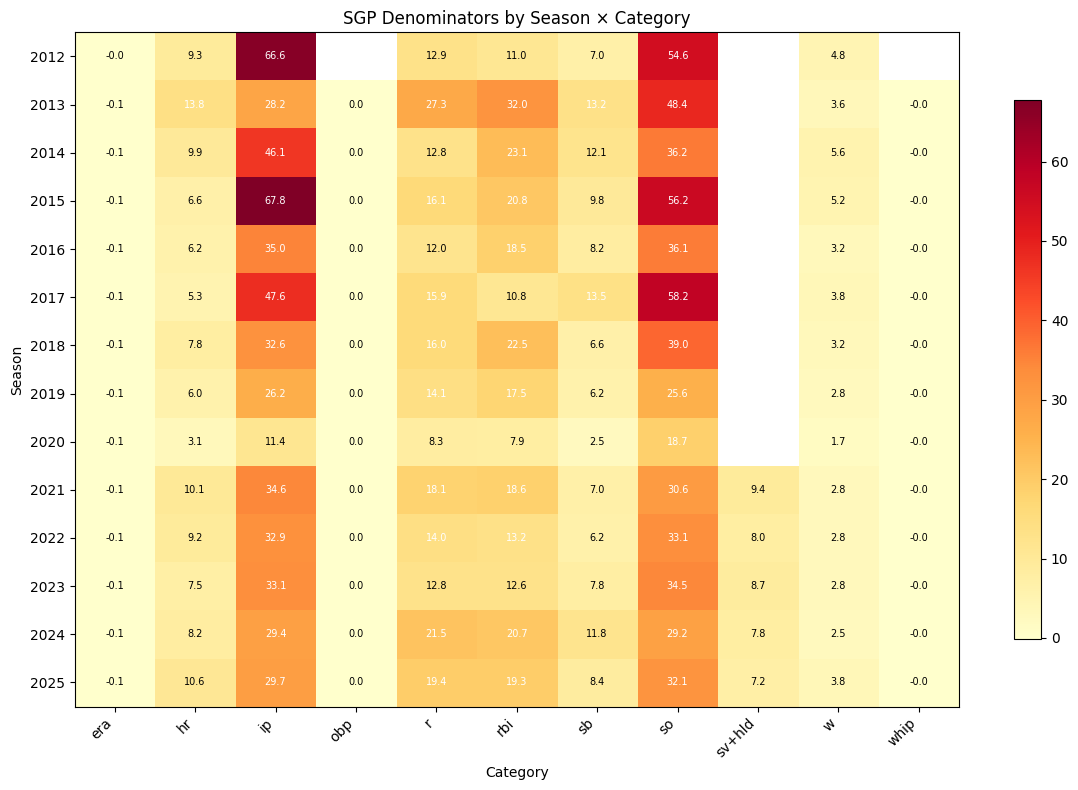

Coefficient of Variation (%) — lower = more stable:
category
sv+hld    11.4
obp       23.5
whip      27.0
era       27.8
w         30.4
r         31.4
hr        31.9
so        32.4
rbi       34.0
sb        36.4
ip        41.1
dtype: float64


In [5]:
# Heatmap of denominators by season × category
pivot = sgp_df.pivot_table(index="season", columns="category", values="sgp_denom")

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index.astype(int))
ax.set_xlabel("Category")
ax.set_ylabel("Season")
ax.set_title("SGP Denominators by Season × Category")

# Annotate cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        if not np.isnan(val):
            ax.text(
                j,
                i,
                f"{val:.1f}",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if val > pivot.values[~np.isnan(pivot.values)].mean() else "black",
            )

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Coefficient of variation
cv = (avg_denoms["std"] / avg_denoms["sgp_denom"].abs() * 100).round(1)
print("Coefficient of Variation (%) — lower = more stable:")
print(cv.sort_values())

## Bar Chart of Average Denominators

Visual sanity check — do the magnitudes make intuitive sense?

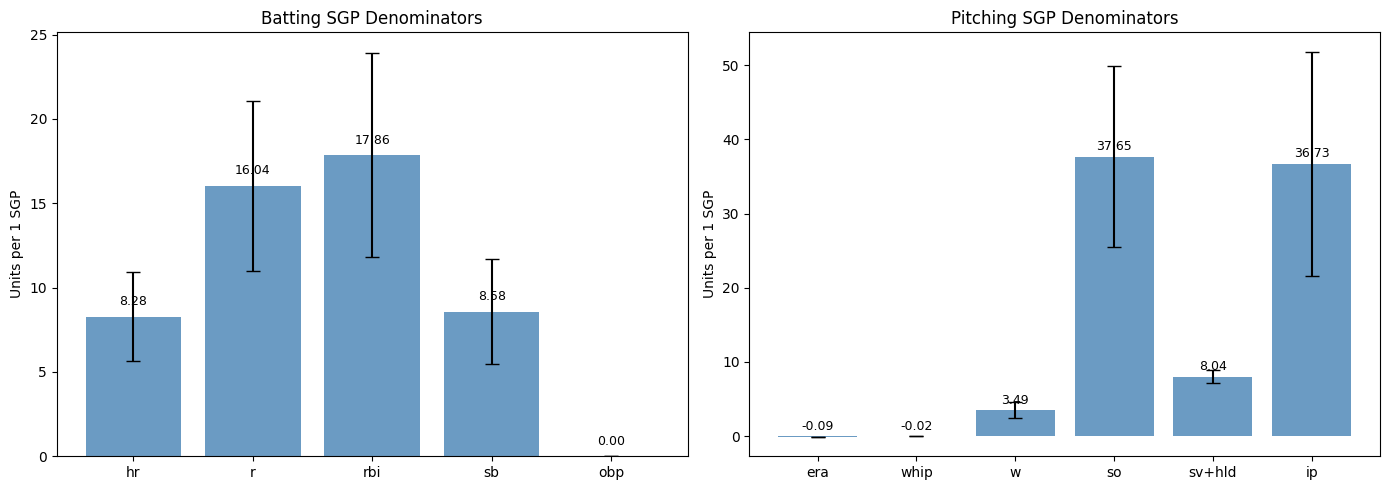

In [6]:
# Separate batting and pitching for cleaner display
batting_cats = ["hr", "r", "rbi", "sb", "obp"]
pitching_cats = ["era", "whip", "w", "so", "sv+hld", "ip"]
batting_cats = [c for c in batting_cats if c in avg_denoms.index]
pitching_cats = [c for c in pitching_cats if c in avg_denoms.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cats, title in [
    (axes[0], batting_cats, "Batting SGP Denominators"),
    (axes[1], pitching_cats, "Pitching SGP Denominators"),
]:
    subset = avg_denoms.loc[cats]
    bars = ax.bar(subset.index, subset["sgp_denom"], yerr=subset["std"], capsize=5, color="steelblue", alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel("Units per 1 SGP")
    # Add value labels
    for bar, val in zip(bars, subset["sgp_denom"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

## League Size Effects

The league changed size over the years (10→14→12→14 teams). More teams = smaller gaps between adjacent teams. Let's check if normalizing by league size helps stability.

Teams per season:
 season  n_teams
   2012       10
   2013       10
   2014       10
   2015       14
   2016       14
   2017       14
   2018       14
   2019       14
   2020       12
   2021       12
   2022       14
   2023       14
   2024       14
   2025       12
   2025       14


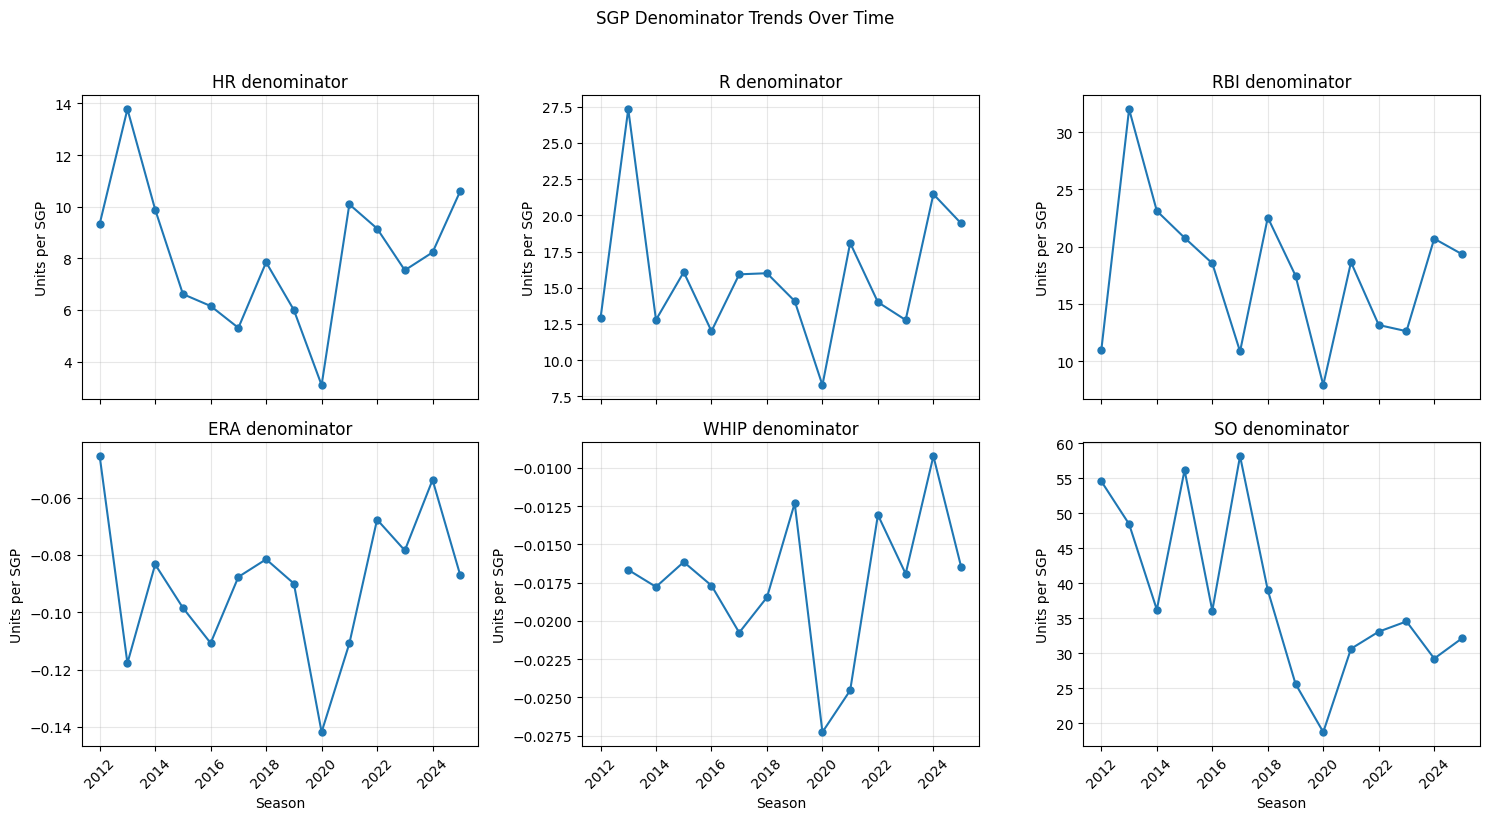

In [7]:
# Show league size by season
league_sizes = completed.groupby(["season", "league_key"]).size().reset_index(name="n_teams")
print("Teams per season:")
print(league_sizes[["season", "n_teams"]].to_string(index=False))

# Plot denomination trends over time for key categories
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
key_cats = ["hr", "r", "rbi", "era", "whip", "so"]
key_cats = [c for c in key_cats if c in pivot.columns]

for ax, cat in zip(axes.flat, key_cats):
    ax.plot(pivot.index, pivot[cat], "o-", markersize=5)
    ax.set_title(f"{cat.upper()} denominator")
    ax.set_ylabel("Units per SGP")
    ax.grid(True, alpha=0.3)
    # Shade league size changes
    for season, row in league_sizes.iterrows():
        pass  # keeping it simple

# Add season labels on bottom row
for ax in axes[1]:
    ax.set_xlabel("Season")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("SGP Denominator Trends Over Time", y=1.02)
plt.tight_layout()
plt.show()

## Quick SGP Valuation Prototype

Use the denominators to compute SGP-based player values for a single holdout season and compare correlation with actual ZAR$ values.

In [8]:
from pathlib import Path
from fantasy_baseball_manager.db.connection import create_connection
from fantasy_baseball_manager.analysis_container import AnalysisContainer

ac_conn = create_connection(Path(DB_PATH))
container = AnalysisContainer(ac_conn)

# Check what actual valuations we have
actuals = pd.read_sql(
    "SELECT DISTINCT season, system, version, projection_system FROM valuation WHERE projection_system = 'actual'",
    conn,
)
print("Available actual valuations:")
actuals

Available actual valuations:


,season,system,version,projection_system
0,2025,zar,1.0,actual
1,2019,zar,1.0,actual
2,2021,zar,1.0,actual
3,2022,zar,1.0,actual
4,2023,zar,1.0,actual
5,2024,zar,1.0,actual


In [9]:
# Load actual batting stats for a holdout season to compute SGP values
# We'll use 2024 as holdout and compute denominators from 2019-2023
HOLDOUT = 2024
DENOM_YEARS = range(2019, 2024)

# Get denominators from non-holdout years
train_denoms = sgp_df[sgp_df["season"].isin(DENOM_YEARS)].groupby("category")["sgp_denom"].mean()
print(f"SGP denominators (trained on {list(DENOM_YEARS)}):")
print(train_denoms.round(4).to_string())

# Load actual batting stats for holdout season (columns are direct, not JSON)
batting = pd.read_sql(
    f"SELECT player_id, pa, hr, r, rbi, sb, obp FROM batting_stats WHERE season = {HOLDOUT} AND pa >= 100",
    conn,
)
print(f"\n{len(batting)} batters with 100+ PA in {HOLDOUT}")

# Load actual pitching stats
pitching = pd.read_sql(
    f"""SELECT player_id, ip, era, whip, w, so, sv + hld as "sv+hld"
    FROM pitching_stats WHERE season = {HOLDOUT} AND ip >= 20""",
    conn,
)
print(f"{len(pitching)} pitchers with 20+ IP in {HOLDOUT}")

SGP denominators (trained on [2019, 2020, 2021, 2022, 2023]):
category
era       -0.0978
hr         7.1748
ip        27.6277
obp        0.0028
r         13.4420
rbi       13.9552
sb         5.9217
so        28.5189
sv+hld     8.6853
w          2.6014
whip      -0.0188

429 batters with 100+ PA in 2024
488 pitchers with 20+ IP in 2024


In [ ]:
from scipy.stats import spearmanr

# Compute raw SGP for each player: stat_value / sgp_denominator
# For rate stats (OBP, ERA, WHIP), we need marginal SGP which requires
# a baseline. For simplicity, use replacement-level approach:
# SGP = (player_stat - replacement_level) / denominator

BATTER_CATS = ["hr", "r", "rbi", "sb", "obp"]
PITCHER_CATS = ["era", "whip", "w", "so", "sv+hld"]


# Replacement level = stat value of the (N_teams * roster_spots + 1)th player
# For a rough prototype, use the median as replacement level
def compute_sgp_values(stats_df, cats, denoms, player_type):
    """Compute total SGP for each player."""
    sgp_total = pd.Series(0.0, index=stats_df.index)
    details = {}
    for cat in cats:
        if cat not in stats_df.columns or cat not in denoms.index:
            continue
        d = denoms[cat]
        if d == 0:
            continue
        col = stats_df[cat].fillna(0)
        replacement = col.median()
        # For ERA/WHIP, being BELOW replacement is good; for counting stats, ABOVE
        cat_sgp = (replacement - col) / abs(d) if cat in LOWER_IS_BETTER else (col - replacement) / d
        sgp_total += cat_sgp
        details[cat] = cat_sgp
    result = stats_df[["player_id"]].copy()
    result["sgp_total"] = sgp_total
    result["player_type"] = player_type
    for cat, vals in details.items():
        result[f"sgp_{cat}"] = vals
    return result


batter_sgp = compute_sgp_values(batting, BATTER_CATS, train_denoms, "batter")
pitcher_sgp = compute_sgp_values(pitching, PITCHER_CATS, train_denoms, "pitcher")

all_sgp = pd.concat([batter_sgp, pitcher_sgp], ignore_index=True)
print(f"Computed SGP values for {len(batter_sgp)} batters and {len(pitcher_sgp)} pitchers")
all_sgp.sort_values("sgp_total", ascending=False).head(10)

In [11]:
# Compare SGP rankings with actual ZAR$ rankings
zar_actuals = pd.read_sql(
    f"""SELECT player_id, value as zar_value, rank as zar_rank
    FROM valuation
    WHERE season = {HOLDOUT} AND projection_system = 'actual' AND system = 'zar'
    """,
    conn,
)
print(f"{len(zar_actuals)} actual ZAR$ valuations for {HOLDOUT}")

# Merge SGP with ZAR$
merged = all_sgp.merge(zar_actuals, on="player_id", how="inner")
print(f"{len(merged)} players matched between SGP and ZAR$")

# Add player names
players = pd.read_sql("SELECT id as player_id, name_first || ' ' || name_last as name FROM player", conn)
merged = merged.merge(players, on="player_id", how="left")

# Compute Spearman rank correlation
rho_all, p_all = spearmanr(merged["sgp_total"], merged["zar_value"])
print(f"\nOverall Spearman ρ (SGP vs ZAR$): {rho_all:.4f} (p={p_all:.2e})")

# By player type
for ptype in ["batter", "pitcher"]:
    sub = merged[merged["player_type"] == ptype]
    if len(sub) > 5:
        rho, p = spearmanr(sub["sgp_total"], sub["zar_value"])
        print(f"  {ptype}: ρ = {rho:.4f} (n={len(sub)})")

# Show top 20 by SGP with their ZAR$ rank
top20 = merged.sort_values("sgp_total", ascending=False).head(20)
print(f"\nTop 20 by SGP total:")
print(top20[["name", "player_type", "sgp_total", "zar_value", "zar_rank"]].to_string(index=False))

1286 actual ZAR$ valuations for 2024
952 players matched between SGP and ZAR$

Overall Spearman ρ (SGP vs ZAR$): 0.5762 (p=2.66e-85)
  batter: ρ = 0.5790 (n=462)
  pitcher: ρ = 0.5773 (n=490)

Top 20 by SGP total:
           name player_type  sgp_total  zar_value  zar_rank
    Aaron Judge      batter  73.941432      98.85         1
 Emmanuel Clase     pitcher  71.461956      42.77        12
  Sean Guenther     pitcher  68.619627       0.00       835
  Shohei Ohtani      batter  57.468866      73.13         2
    Kirby Yates     pitcher  57.234620      28.39        31
      Juan Soto      batter  55.291457      66.81         3
  Hunter Gaddis     pitcher  55.249176      28.37        32
   Bryan Hudson     pitcher  53.429865      11.50       105
Raisel Iglesias     pitcher  53.024067      26.15        41
    Matt Strahm     pitcher  51.965994      16.42        75
    Ryan Walker     pitcher  49.579120      34.36        24
 Danny Coulombe     pitcher  48.994643       0.00       824
    Ed

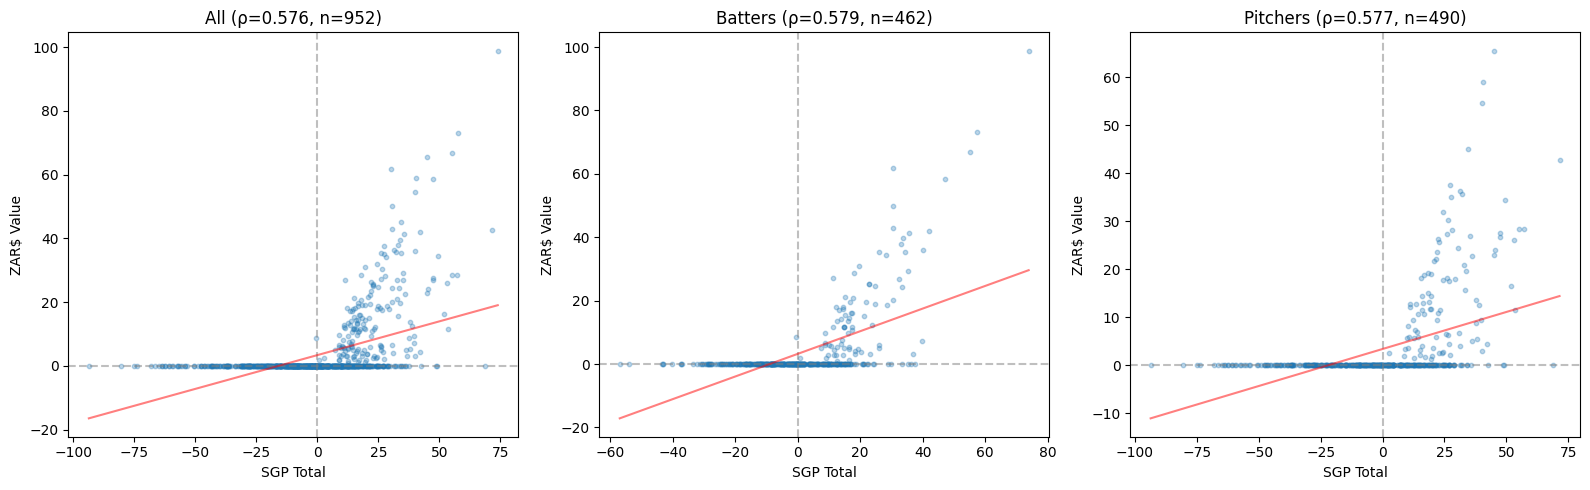

In [12]:
# Scatter: SGP total vs ZAR$ value
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, sub) in zip(
    axes,
    [
        ("All", merged),
        ("Batters", merged[merged["player_type"] == "batter"]),
        ("Pitchers", merged[merged["player_type"] == "pitcher"]),
    ],
):
    if len(sub) < 2:
        continue
    rho, _ = spearmanr(sub["sgp_total"], sub["zar_value"])
    ax.scatter(sub["sgp_total"], sub["zar_value"], alpha=0.3, s=10)
    ax.set_xlabel("SGP Total")
    ax.set_ylabel("ZAR$ Value")
    ax.set_title(f"{label} (ρ={rho:.3f}, n={len(sub)})")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    # Add trend line
    z = np.polyfit(sub["sgp_total"], sub["zar_value"], 1)
    x_line = np.linspace(sub["sgp_total"].min(), sub["sgp_total"].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), "r-", alpha=0.5)

plt.tight_layout()
plt.show()

## Biggest Disagreements: Where SGP and ZAR$ Diverge

Players where SGP ranking differs most from ZAR$ ranking — these are the interesting cases where the two valuation systems disagree on player value.

In [13]:
# Rank players by SGP and ZAR$, find biggest discrepancies
merged["sgp_rank"] = merged["sgp_total"].rank(ascending=False)
merged["rank_diff"] = merged["sgp_rank"] - merged["zar_rank"]

print("Players SGP likes MORE than ZAR$ (negative rank_diff = SGP ranks higher):")
sgp_favorites = merged.nsmallest(10, "rank_diff")
print(
    sgp_favorites[["name", "player_type", "sgp_rank", "zar_rank", "rank_diff", "sgp_total", "zar_value"]].to_string(
        index=False
    )
)

print("\nPlayers ZAR$ likes MORE than SGP (positive rank_diff = ZAR$ ranks higher):")
zar_favorites = merged.nlargest(10, "rank_diff")
print(
    zar_favorites[["name", "player_type", "sgp_rank", "zar_rank", "rank_diff", "sgp_total", "zar_value"]].to_string(
        index=False
    )
)

Players SGP likes MORE than ZAR$ (negative rank_diff = SGP ranks higher):
           name player_type  sgp_rank  zar_rank  rank_diff  sgp_total  zar_value
      Kaleb Ort     pitcher      38.0      1184    -1146.0  35.856187        0.0
 J. T. Chargois     pitcher      69.0      1178    -1109.0  28.946451        0.0
   Matt Wallner      batter     138.5      1040     -901.5  21.054287        0.0
   A. J. Minter     pitcher      86.0       986     -900.0  26.745741        0.0
   Nick Sandlin     pitcher     394.0      1270     -876.0   4.349151        0.0
Victor González     pitcher     371.0      1240     -869.0   6.496934        0.0
  Shelby Miller     pitcher     308.0      1176     -868.0  10.408263        0.0
   Jake Cousins     pitcher      82.0       938     -856.0  26.931091        0.0
   Tommy Kahnle     pitcher     107.0       963     -856.0  24.398054        0.0
 Erasmo Ramírez     pitcher     402.0      1255     -853.0   4.114696        0.0

Players ZAR$ likes MORE than SGP (